<a href="https://colab.research.google.com/github/engMohamedAbdAlslam/DRP_segmentation/blob/copilot%2Fdevelop-preprocessing-pipeline/notebooks/05_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Test Set Evaluation
**Goal:** Evaluate the best trained EfficientNet-B4 on the held-out test set.
**Metrics:** Accuracy, QWK, Precision, Recall, F1 (per-class), Confusion Matrix
> Run on **Google Colab** with T4 GPU. Drive must be mounted with NB01 output at `DRP_processed/aptos2019/` and the best model at `DRP_processed/best_efficientnet_b4.pth`.

## 1. Colab Repo Setup

In [15]:
import os
from pathlib import Path

repo_path = Path('/content/DRP_segmentation')
if not repo_path.exists():
    !git clone https://github.com/engMohamedAbdAlslam/DRP_segmentation.git /content/DRP_segmentation

%cd /content/DRP_segmentation
!git checkout copilot/develop-preprocessing-pipeline
!git pull origin copilot/develop-preprocessing-pipeline
print('Repo ready.')

/content/DRP_segmentation
Already on 'copilot/develop-preprocessing-pipeline'
Your branch is up to date with 'origin/copilot/develop-preprocessing-pipeline'.
From https://github.com/engMohamedAbdAlslam/DRP_segmentation
 * branch            copilot/develop-preprocessing-pipeline -> FETCH_HEAD
Already up to date.
Repo ready.


## 2. Install Dependencies

In [16]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                'timm', 'opencv-python-headless', 'tqdm',
                'matplotlib', 'scikit-learn', 'numpy', 'pandas', 'seaborn'],
               check=True)
print('Dependencies ready.')

Dependencies ready.


## 3. Mount Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Imports & Config

In [21]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import timm

from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                             classification_report)
from torch.amp import autocast

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DRIVE_BASE  = Path('/content/drive/MyDrive/DRP_processed/aptos2019')
MODEL_PATH  = Path('/content/drive/MyDrive/DRP_models/efficientnet_b4_dr_grading.pth')
MODEL_NAME  = 'efficientnet_b4'
NUM_CLASSES = 5
BATCH_SIZE  = 16
DR_NAMES    = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}

print(f'Device: {DEVICE}')
print(f'Model path exists: {MODEL_PATH.exists()}')

Device: cpu
Model path exists: True


## 5. Dataset Class

In [22]:
class APTOSDataset(Dataset):
    def __init__(self, split_dir: Path):
        self.files = sorted(split_dir.rglob('*.npz'))
        assert len(self.files) > 0, f'No .npz files in {split_dir}'

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data  = np.load(self.files[idx], allow_pickle=True)
        image = torch.from_numpy(data['image'].astype(np.float32)).permute(2, 0, 1)
        label = int(self.files[idx].stem.split('_grade')[-1])
        return image, label

test_ds     = APTOSDataset(DRIVE_BASE / 'test')
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
print(f'Test samples: {len(test_ds)}')

Test samples: 440


## 6. Load Model

In [23]:
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print('Model loaded successfully.')

Model loaded successfully.


## 7. Run Inference on Test Set

In [24]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(DEVICE)
        with autocast('cuda'):
            outputs = model(images)
        probs  = torch.softmax(outputs, dim=1)
        preds  = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Core metrics
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
acc = (all_preds == all_labels).mean()
print(f'\n{"="*40}')
print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Test QWK      : {qwk:.4f}')
print(f'{"="*40}')

Testing:   0%|          | 0/28 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_1817/996968766.py:6: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast('cuda'):
Testing: 100%|██████████| 28/28 [08:27<00:00, 18.13s/it]


Test Accuracy : 0.8341 (83.41%)
Test QWK      : 0.9034


## 8. Classification Report

In [25]:
print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=[DR_NAMES[i] for i in range(NUM_CLASSES)],
    digits=3
))


Classification Report:
               precision    recall  f1-score   support

        No DR      0.986     0.953     0.969       215
         Mild      0.580     0.644     0.611        45
     Moderate      0.787     0.787     0.787       122
       Severe      0.565     0.565     0.565        23
Proliferative      0.649     0.686     0.667        35

     accuracy                          0.834       440
    macro avg      0.713     0.727     0.720       440
 weighted avg      0.840     0.834     0.837       440



## 9. Confusion Matrix

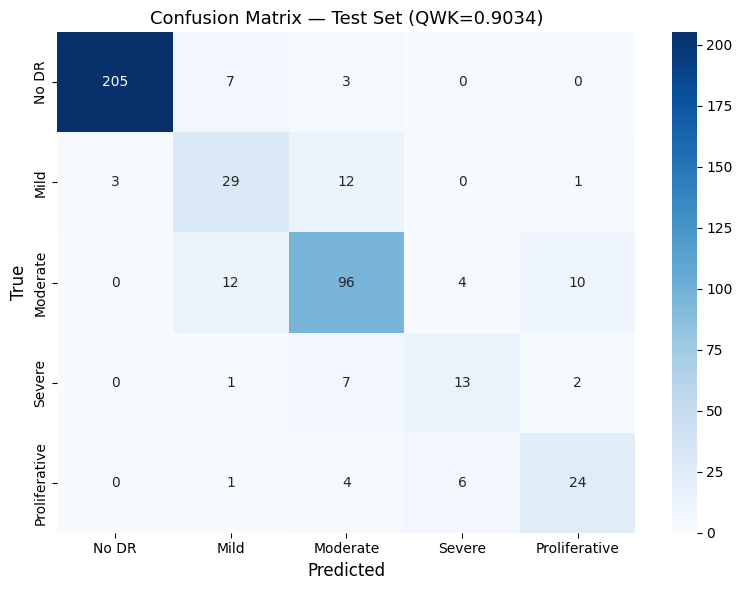

Saved: /content/confusion_matrix.png


In [26]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[DR_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[DR_NAMES[i] for i in range(NUM_CLASSES)])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Set (QWK={qwk:.4f})', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix.png')

## 10. Per-Class Accuracy

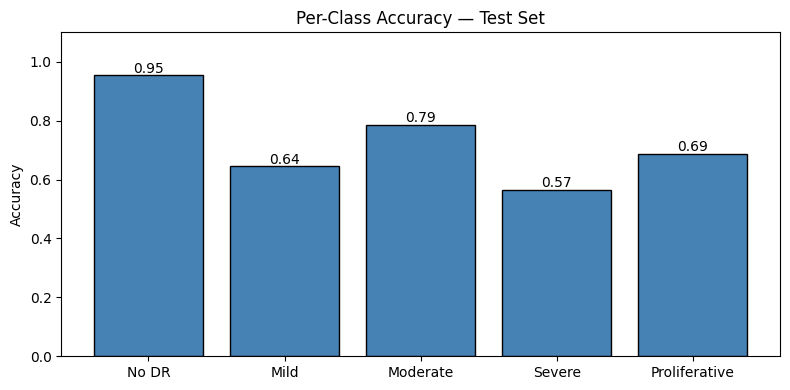

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = ax.bar([DR_NAMES[i] for i in range(NUM_CLASSES)],
              per_class_acc, color='steelblue', edgecolor='black')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy — Test Set')
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150)
plt.show()

## 11. Save Results to Drive

In [28]:
results_df = pd.DataFrame({
    'true_label':      all_labels,
    'pred_label':      all_preds,
    'true_grade_name': [DR_NAMES[l] for l in all_labels],
    'pred_grade_name': [DR_NAMES[p] for p in all_preds],
    **{f'prob_grade{i}': all_probs[:, i] for i in range(NUM_CLASSES)}
})

save_dir = Path('/content/drive/MyDrive/DRP_models')
results_df.to_csv(save_dir / 'test_results.csv', index=False)

import shutil
shutil.copy('/content/confusion_matrix.png',   save_dir / 'confusion_matrix.png')
shutil.copy('/content/per_class_accuracy.png', save_dir / 'per_class_accuracy.png')

print(f'Results saved to {save_dir}')
print(f'Total test samples   : {len(results_df)}')
print(f'Correct predictions  : {(results_df.true_label == results_df.pred_label).sum()}')
print(f'Final Test Accuracy  : {acc:.4f}')
print(f'Final Test QWK       : {qwk:.4f}')

Results saved to /content/drive/MyDrive/DRP_models
Total test samples   : 440
Correct predictions  : 367
Final Test Accuracy  : 0.8341
Final Test QWK       : 0.9034


## Grad-CAM Setup

In [31]:
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

GRADCAM_SAVE_DIR = Path('/content/drive/MyDrive/DRP_models/gradcam_results')
GRADCAM_SAVE_DIR.mkdir(parents=True, exist_ok=True)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


target_layer = model.blocks[-1]
gradcam = GradCAM(model, target_layer)
print("✅ Grad-CAM ready:", target_layer.__class__.__name__)

✅ Grad-CAM ready: Sequential


## Visualize

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


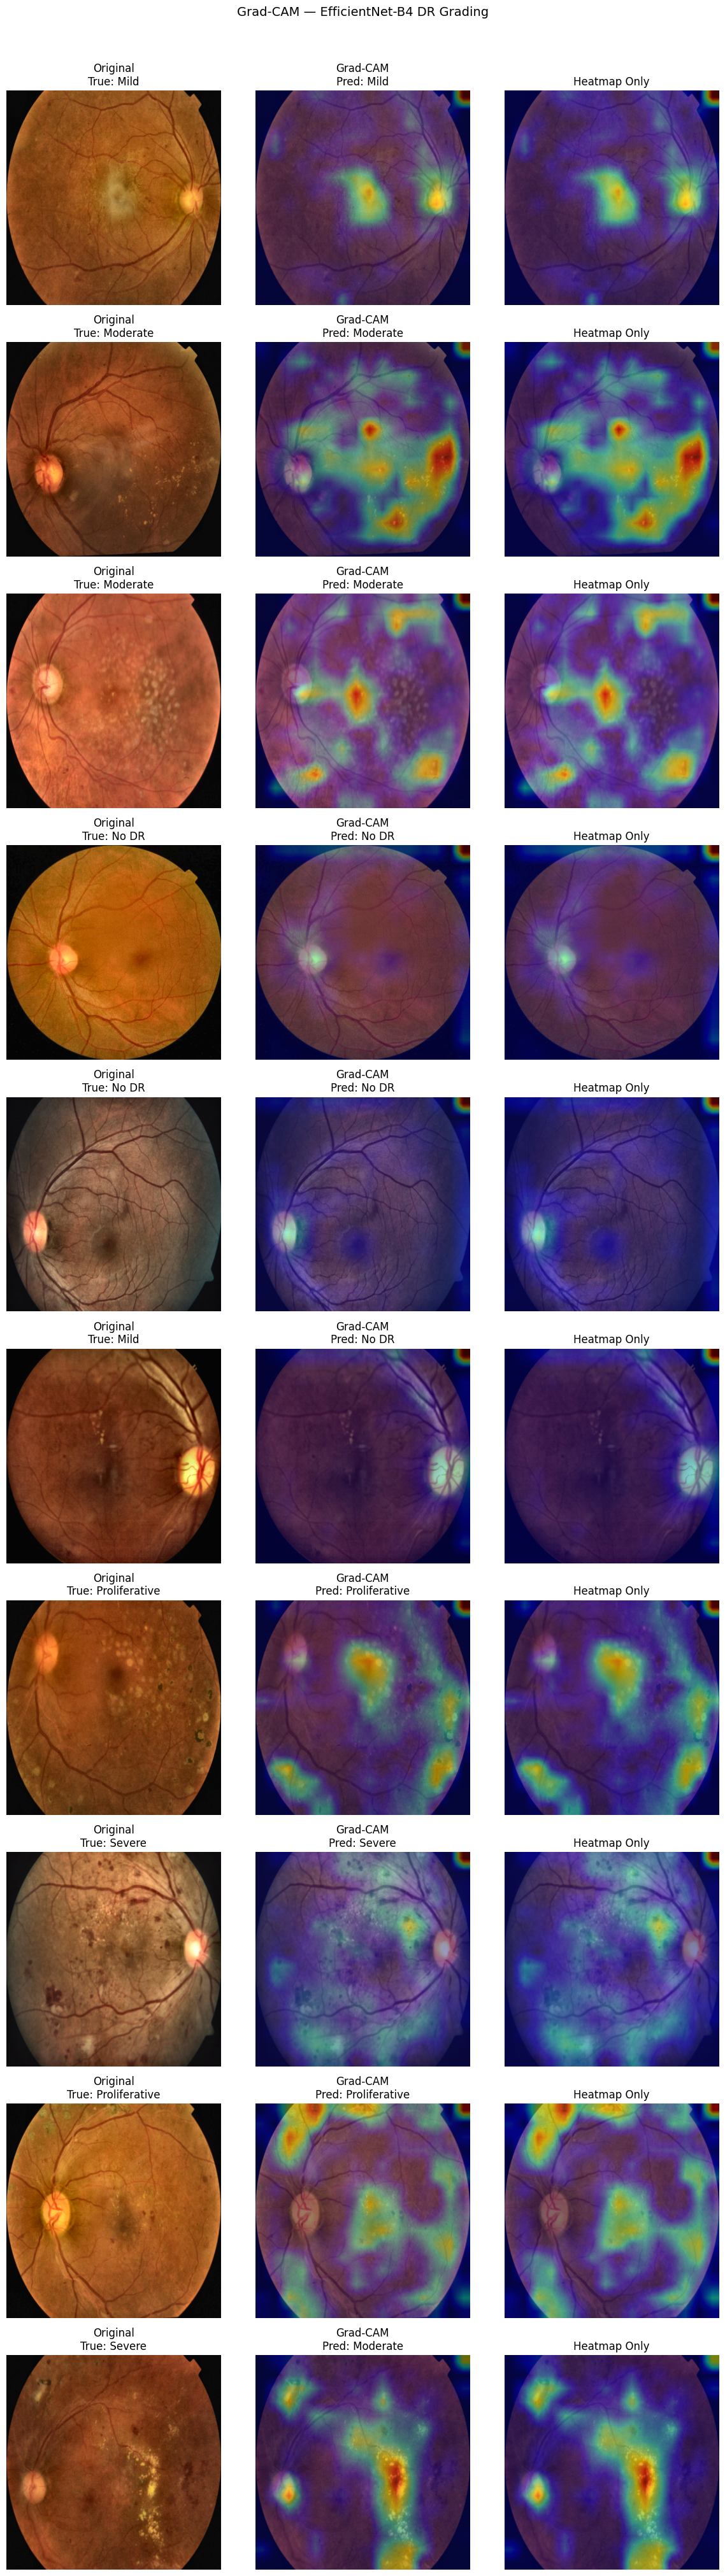

✅ Saved to /content/drive/MyDrive/DRP_models/gradcam_results


In [32]:
def overlay_gradcam(img_tensor, cam, alpha=0.4):

    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = img_np.clip(0, 1)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = alpha * heatmap + (1 - alpha) * img_np
    return img_np, overlay.clip(0, 1)


model.eval()
samples_per_class = 2
shown = {i: 0 for i in range(NUM_CLASSES)}
sample_images, sample_labels = [], []

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        c = lbl.item()
        if shown[c] < samples_per_class:
            sample_images.append(img.unsqueeze(0))
            sample_labels.append(c)
            shown[c] += 1
    if all(v >= samples_per_class for v in shown.values()):
        break

# Plot
fig, axes = plt.subplots(len(sample_images), 3,
                         figsize=(12, 4 * len(sample_images)))

for idx, (img_t, true_label) in enumerate(zip(sample_images, sample_labels)):
    img_t = img_t.to(DEVICE)
    cam, pred_idx = gradcam.generate(img_t)
    orig, overlay = overlay_gradcam(img_t.cpu(), cam)

    axes[idx, 0].imshow(orig)
    axes[idx, 0].set_title(f'Original\nTrue: {DR_NAMES[true_label]}')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title(f'Grad-CAM\nPred: {DR_NAMES[pred_idx]}')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(orig)
    axes[idx, 2].imshow(cam, cmap='jet', alpha=0.5)
    axes[idx, 2].set_title('Heatmap Only')
    axes[idx, 2].axis('off')

plt.suptitle('Grad-CAM — EfficientNet-B4 DR Grading', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(GRADCAM_SAVE_DIR / 'gradcam_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Saved to {GRADCAM_SAVE_DIR}")